### House Price Analysis

#### 1. Introduction

This project uses Python-based data analytics to explore a housing dataset and identify patterns in house prices. 
The goal is to analyse how property characteristics are associated with house prices.

The analysis focuses on descriptive statistics, data quality, group-based comparisons, correlation analysis, and visualizations. 
Generative AI / IBM Bob is used as an analytical support tool for understanding the dataset, developing analytical questions, explaining code, and improving documentation.

#### 2. Problem Statement

Housing prices vary according to many property characteristics.
The purpose of this project is to:

- Analyse the available housing data
- Identify important patterns and relationships
- Compare different property categories
- Generate meaningful insights using data analytics and AI-assisted interpretation

The analysis answers the question:  

**Which property characteristics show the strongest association with higher or lower house prices in this dataset?**

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully.")
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

Dataset loaded successfully.
  Rows    : 545
  Columns : 13


#### 3. Understand the Dataset

Before any analysis, we take a first look at the data to understand its structure, column names, data types, and basic statistics.

In [5]:
# First 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
# last 5 rows
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
# Dataset shape
rows, cols = df.shape
print(f"Number of rows    : {rows}")
print(f"Number of columns : {cols}")

In [8]:
# column names
print("Column names:")
print(df.columns.tolist())

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [ ]:
df.info()

In [ ]:
df.describe()

#### 4. Data Quality Check

Good data analytics starts with clean data. We check for:
- missing values (nulls)
- duplicate rows
- the spread of categorical values


In [9]:
# MISSIN VALUES
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
# DUPLICATE ROWS
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

if dup_count == 0:
    print("Result: No duplicate rows — dataset is clean.")
else:
    print(f"Warning: {dup_count} duplicate rows detected.")

Number of duplicate rows: 0
Result: No duplicate rows — dataset is clean.


In [11]:
# List of columns with categorical / binary values
cat_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea", "furnishingstatus"]

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


mainroad:
mainroad
yes    468
no      77

guestroom:
guestroom
no     448
yes     97

basement:
basement
no     354
yes    191

hotwaterheating:
hotwaterheating
no     520
yes     25

airconditioning:
airconditioning
no     373
yes    172

prefarea:
prefarea
no     417
yes    128

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140


#### 5. Exploratory Data Analysis

##### 5.1 Price Summary Statistics

Key descriptive statistics for the target variable.


In [ ]:
price_mean = df['price'].mean()
price_median = df['price'].median()
price_min    = df['price'].min()
price_max    = df['price'].max()
price_std    = df['price'].std()

print("House Price Summary")
print("-" * 40)
print(f"  Mean price    : Rs {price_mean:>12,.0f}")
print(f"  Median price  : Rs {price_median:>12,.0f}")
print(f"  Minimum price : Rs {price_min:>12,.0f}")
print(f"  Maximum price : Rs {price_max:>12,.0f}")
print(f"  Std deviation : Rs {price_std:>12,.0f}")
print(f"\n  Price range (max - min): Rs {price_max - price_min:,.0f}")

House Price Summary
----------------------------------------
  Mean price    : Rs    4,766,729
  Median price  : Rs    4,340,000
  Minimum price : Rs    1,750,000
  Maximum price : Rs   13,300,000
  Std deviation : Rs    1,870,440

  Price range (max - min): Rs 11,550,000


##### 5.2 Price Distribution — Histogram

A histogram shows how house prices are spread across the dataset.
The x-axis shows price in Rs Lakhs; the y-axis shows how many properties fall in each price band.

C:\Users\Suraj\AppData\Local\Temp\ipykernel_40004\671385850.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


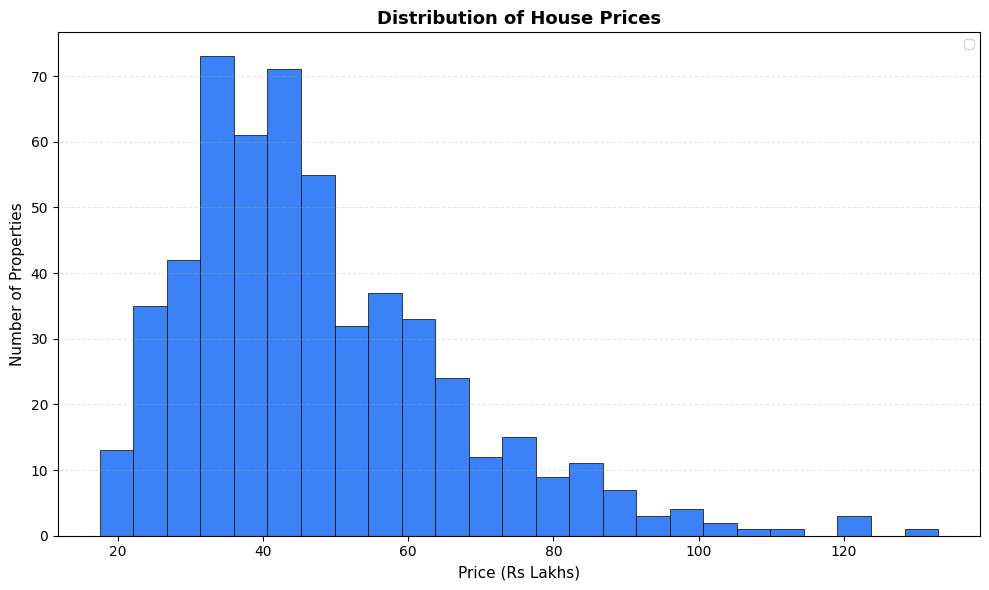

Observation: The distribution is right-skewed — most properties are priced
in the lower-to-middle range, with fewer high-value properties pulling the
mean above the median.


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["price"] / 1e5, bins=25, color="#3b82f6", edgecolor="black", linewidth=0.5)

plt.xlabel("Price (Rs Lakhs)", fontsize=11)
plt.ylabel("Number of Properties", fontsize=11)
plt.title("Distribution of House Prices", fontsize=13, fontweight="bold")
plt.legend(fontsize=9)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

##### 5.3 Numeric Feature Overview

A summary of all numeric features side by side.


In [16]:
num_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
print(df[num_cols].describe().round(2).to_string())

             price      area  bedrooms  bathrooms  stories  parking
count       545.00    545.00    545.00     545.00   545.00   545.00
mean    4766729.25   5150.54      2.97       1.29     1.81     0.69
std     1870439.62   2170.14      0.74       0.50     0.87     0.86
min     1750000.00   1650.00      1.00       1.00     1.00     0.00
25%     3430000.00   3600.00      2.00       1.00     1.00     0.00
50%     4340000.00   4600.00      3.00       1.00     2.00     0.00
75%     5740000.00   6360.00      3.00       2.00     2.00     1.00
max    13300000.00  16200.00      6.00       4.00     4.00     3.00


#### 6. Analytical Questions

We answer 9 analytical questions using actual calculations from the dataset.
Each question includes a summary table, a chart, and a brief interpretation.

> All groupby summaries are computed by pandas at runtime — nothing is hard-coded.

##### Q1. What is the relationship between area and house price?

In [17]:
# Calculate Pearson correlation between area and price
corr_area_price = df["area"].corr(df["price"])
print(f"Pearson correlation (area vs price): {corr_area_price:.4f}")

Pearson correlation (area vs price): 0.5360


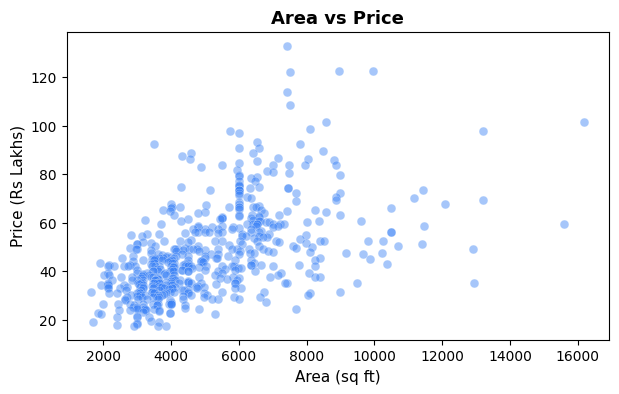

In [21]:
# Scatter plot: area vs price
plt.figure(figsize=(7, 4))
plt.scatter(df["area"], df["price"] / 1e5,alpha=0.45, color="#3b82f6", edgecolors="white",
            linewidths=0.3, s=40)
plt.xlabel("Area (sq ft)", fontsize=11)
plt.ylabel("Price (Rs Lakhs)", fontsize=11)
plt.title(f"Area vs Price",fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

Area shows a **moderate positive association** with price (r ≈ 0.54). Larger properties tend to have higher prices, but the wide scatter indicates that other features also play a meaningful role in determining price.

##### Q2. How does the number of bedrooms relate to house price?

In [22]:
bedroom_summary = (
    df.groupby("bedrooms")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(bedroom_summary.to_string(index=False))

 bedrooms  Count  Mean_Price  Median_Price
        1      2   2712500.0     2712500.0
        2    136   3632022.0     3535000.0
        3    300   4954598.0     4620000.0
        4     95   5729758.0     5250000.0
        5     10   5819800.0     5582500.0
        6      2   4791500.0     4791500.0


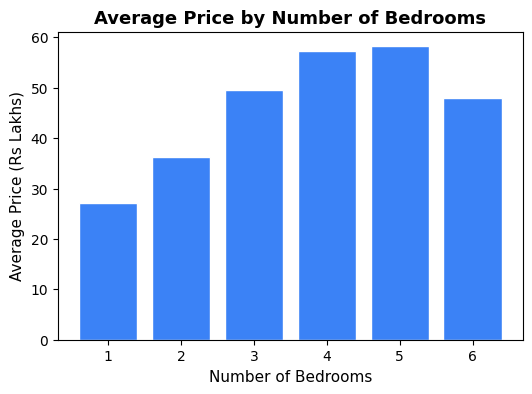

In [23]:
plt.figure(figsize=(6, 4))
plt.bar(bedroom_summary["bedrooms"].astype(str),
        bedroom_summary["Mean_Price"] / 1e5,
        color='#3b82f6', edgecolor='white')
plt.xlabel("Number of Bedrooms", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Number of Bedrooms", fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

Average house price generally rises with bedroom count up to 5 bedrooms. The 6-bedroom category contains very few properties, so its average is less representative of a broader pattern.

##### Q3. How are house prices related to the number of bathrooms?


In [25]:
bathroom_summary = (
    df.groupby("bathrooms")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(bathroom_summary.to_string(index=False))

 bathrooms  Count  Mean_Price  Median_Price
         1    401   4206913.0     3990000.0
         2    133   6209206.0     6090000.0
         3     10   7282100.0     7315000.0
         4      1  12250000.0    12250000.0


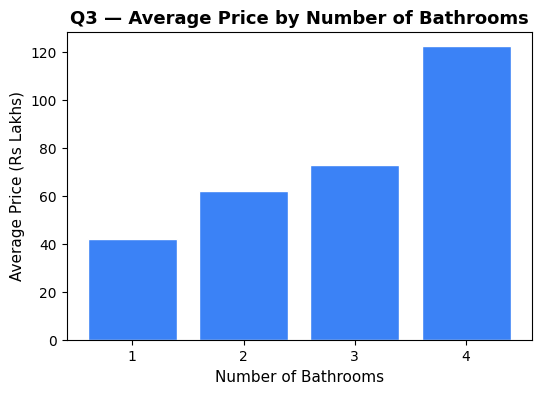

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(bathroom_summary["bathrooms"].astype(str),
        bathroom_summary["Mean_Price"] / 1e5,
        color="#3b82f6", edgecolor="white")
plt.xlabel("Number of Bathrooms", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Number of Bathrooms",fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

Bathrooms show a **strong positive association** with price. Properties with more bathrooms consistently achieve a higher average price, suggesting bathrooms are one of the more influential features in this dataset.

##### Q4. How do house prices vary according to the number of stories?


In [27]:
stories_summary = (
    df.groupby("stories")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(stories_summary.to_string(index=False))

 stories  Count  Mean_Price  Median_Price
       1    227   4170659.0     3850000.0
       2    238   4764074.0     4308500.0
       3     39   5685436.0     5873000.0
       4     41   7208450.0     7350000.0


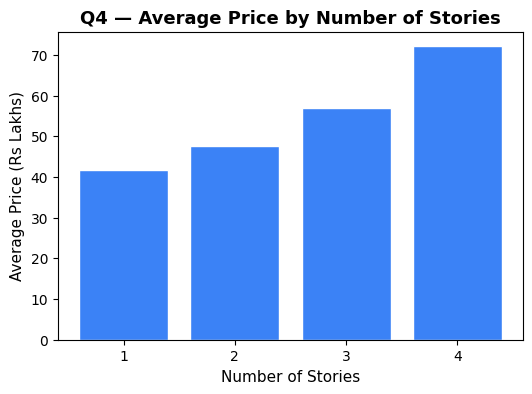

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(stories_summary["stories"].astype(str),
        stories_summary["Mean_Price"] / 1e5,
        color="#3b82f6", edgecolor="white")
plt.xlabel("Number of Stories", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Number of Stories",fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

More floors are consistently associated with a higher average price, suggesting that multi-storey properties are valued more highly in this dataset.


##### Q5. How does furnishing status relate to house prices?

In [29]:
furnishing_summary = (
    df.groupby("furnishingstatus")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
    .sort_values('Mean_Price', ascending=False)
)
print(furnishing_summary.to_string(index=False))

furnishingstatus  Count  Mean_Price  Median_Price
       furnished    140   5495696.0     5075000.0
  semi-furnished    227   4907524.0     4585000.0
     unfurnished    178   4013831.0     3430000.0


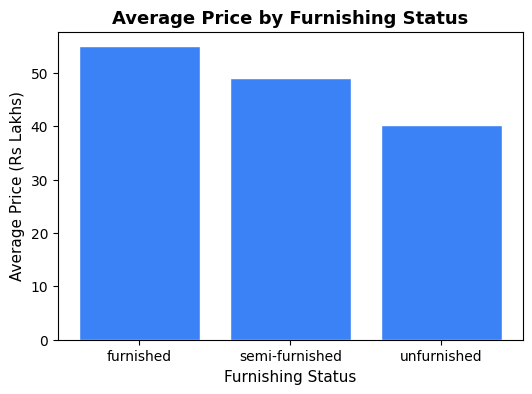

In [30]:
plt.figure(figsize=(6, 4))
plt.bar(furnishing_summary["furnishingstatus"],
        furnishing_summary["Mean_Price"] / 1e5,
        color="#3b82f6", edgecolor="white")
plt.xlabel("Furnishing Status", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Furnishing Status",
          fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

Furnished homes show the highest average price, followed by semi-furnished, then unfurnished. This suggests furnishing status is associated with meaningful price differences in this dataset.


##### Q6. How does the number of parking spaces relate to house prices?

In [32]:
parking_summary = (
    df.groupby("parking")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(parking_summary.to_string(index=False))

 parking  Count  Mean_Price  Median_Price
       0    299   4136017.0     3850000.0
       1    126   5190389.0     4690000.0
       2    108   5896328.0     5302500.0
       3     12   5867167.0     4375000.0


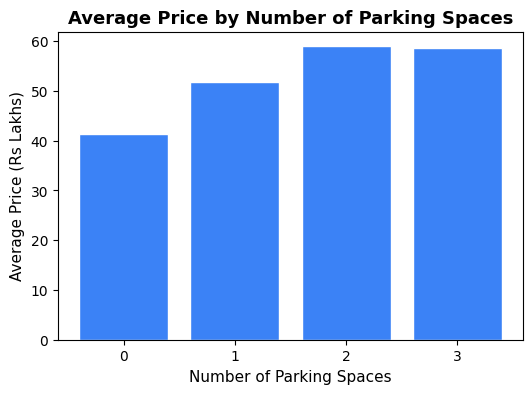

In [33]:
plt.figure(figsize=(6, 4))
plt.bar(parking_summary["parking"].astype(str),
        parking_summary["Mean_Price"] / 1e5,
        color="#3b82f6", edgecolor="white")
plt.xlabel("Number of Parking Spaces", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Number of Parking Spaces", fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

More parking spaces are associated with higher average prices, though the increase levels off at 2–3 spaces due to fewer properties in those categories.

##### Q7. Do houses with air conditioning have different price patterns?

In [34]:
ac_summary = (
    df.groupby("airconditioning")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(ac_summary.to_string(index=False))

# Calculate the observed price difference dynamically
yes_price = float(ac_summary.loc[ac_summary["airconditioning"] == "yes", "Mean_Price"].values[0])
no_price  = float(ac_summary.loc[ac_summary["airconditioning"] == "no",  "Mean_Price"].values[0])
diff_pct  = ((yes_price - no_price) / no_price) * 100
print(f"\nObserved difference: houses with AC have a {diff_pct:.1f}% higher average price.")

airconditioning  Count  Mean_Price  Median_Price
             no    373   4191940.0     3885000.0
            yes    172   6013221.0     5757500.0

Observed difference: houses with AC have a 43.4% higher average price.


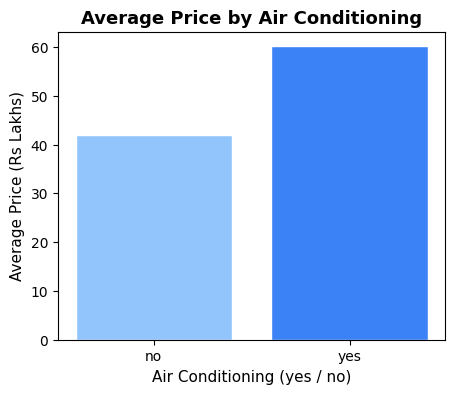

In [35]:
plt.figure(figsize=(5, 4))
plt.bar(ac_summary["airconditioning"],
        ac_summary["Mean_Price"] / 1e5,
        color=["#93c5fd", "#3b82f6"], edgecolor="white")
plt.xlabel("Air Conditioning (yes / no)", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Air Conditioning",
          fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**  

Properties with air conditioning show a notably higher average price compared to those without, indicating that AC is associated with higher-value properties in this dataset.


##### Q8. Do houses in the preferred area have different price patterns?

In [36]:
prefarea_summary = (
    df.groupby("prefarea")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(prefarea_summary.to_string(index=False))

prefarea  Count  Mean_Price  Median_Price
      no    417   4425299.0     4095000.0
     yes    128   5879046.0     5582500.0


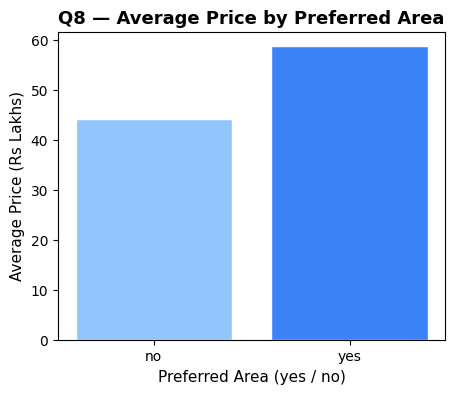

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(prefarea_summary["prefarea"],
        prefarea_summary["Mean_Price"] / 1e5,
        color=["#93c5fd", "#3b82f6"], edgecolor="white")
plt.xlabel("Preferred Area (yes / no)", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Preferred Area",
          fontsize=13, fontweight="bold")
plt.show()

**Interpretation:**

Properties in a preferred area show a significantly higher average price, confirming that location is an important factor associated with higher house prices in this dataset.

##### Q9. Does main-road access show a difference in house prices?

In [ ]:
mainroad_summary = (
    df.groupby("mainroad")["price"]
    .agg(Count="count", Mean_Price="mean", Median_Price="median")
    .round(0)
    .reset_index()
)
print(mainroad_summary.to_string(index=False))

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(mainroad_summary["mainroad"],
        mainroad_summary["Mean_Price"] / 1e5,
        color=["#93c5fd", "#3b82f6"], edgecolor="white")
plt.xlabel("Main Road Access (yes / no)", fontsize=11)
plt.ylabel("Average Price (Rs Lakhs)", fontsize=11)
plt.title("Average Price by Main Road Access",
          fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

**Interpretation:**  

Houses with main-road access show a notably higher average price than those without, highlighting that road accessibility is associated with higher property values.

#### 7. Correlation Analysis

**What is correlation?**  
Pearson correlation measures the strength and direction of a *linear*
relationship between two numeric variables:

- A value close to +1 → strong positive relationship (both rise together)
- A value close to 0 → little or no linear relationship
- A value close to -1 → strong negative relationship (one rises as the other falls)

> **Important:** Correlation shows association, not causation.
> A high correlation does not mean one variable *causes* the other to change.

In [40]:
num_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
corr_matrix = df[num_cols].corr().round(3)
print("Pearson Correlation Matrix:")
print(corr_matrix)

Pearson Correlation Matrix:
           price   area  bedrooms  bathrooms  stories  parking
price      1.000  0.536     0.366      0.518    0.421    0.384
area       0.536  1.000     0.152      0.194    0.084    0.353
bedrooms   0.366  0.152     1.000      0.374    0.409    0.139
bathrooms  0.518  0.194     0.374      1.000    0.326    0.177
stories    0.421  0.084     0.409      0.326    1.000    0.046
parking    0.384  0.353     0.139      0.177    0.046    1.000


In [42]:
print("\nCorrelation with price (sorted):")
print(corr_matrix["price"].drop("price").sort_values(ascending=False).to_string())


Correlation with price (sorted):
area         0.536
bathrooms    0.518
stories      0.421
parking      0.384
bedrooms     0.366


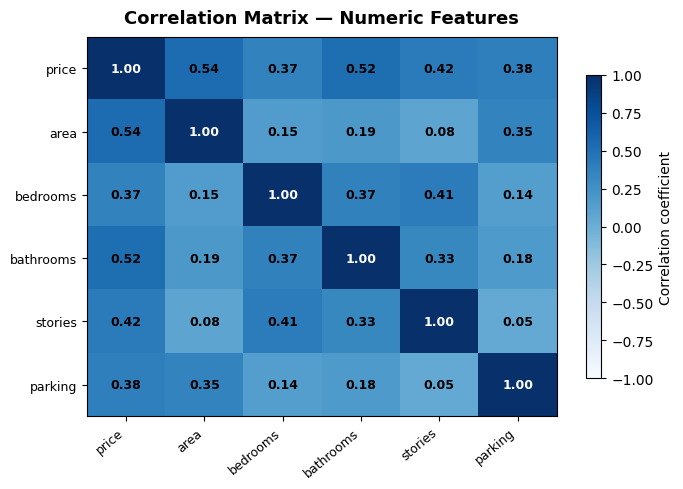

In [43]:
# Visualise the correlation matrix as a heatmap using pure Matplotlib
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix.values, cmap="Blues", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation coefficient')

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

# Annotate each cell with its correlation value
for r in range(len(num_cols)):
    for c in range(len(num_cols)):
        val = corr_matrix.values[r, c]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

ax.set_title("Correlation Matrix — Numeric Features",
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

**Key observations:**
- `bathrooms` shows the strongest positive correlation with `price` among numeric features.
- `area` shows a moderate positive correlation with `price`.
- `bedrooms`, `stories`, and `parking` show weaker but still positive correlations.
- All correlations are positive — no numeric feature in this dataset is
  negatively correlated with price.


#### 8. AI-Assisted Data Analysis

##### Role of Generative AI in this project

Generative AI and IBM Bo are used as supporting tools in this project. The actual numerical calculations remain in Python and are based on `Housing.csv`.
---

##### Core principle

> **Python performs the calculations and produces the evidence.**  
> **Generative AI is used as an analytical support tool** to help formulate
> questions, understand results, improve explanations, and assist with
> documentation.

AI does **not** invent numerical results. Every number in this notebook comes from Python running against the actual dataset.

---

##### How IBM Bob / Generative AI was used

| # | Task | How AI helped |
|---|------|---------------|
| 1 | **Understanding dataset columns** | AI explained what each column represents and which are numeric vs categorical |
| 2 | **Generating analytical questions** | AI suggested relevant business questions to explore from the dataset |
| 3 | **Choosing visualization types** | AI recommended appropriate chart types (scatter, bar, histogram) for each question |
| 4 | **Explaining Python/pandas code** | AI clarified how `groupby`, `agg`, `corr`, and `pd.cut` work |
| 5 | **Interpreting calculated results** | AI helped frame interpretations after the calculations were complete |
| 6 | **Improving code readability** | AI suggested clearer variable names and added inline comments |
| 7 | **Debugging Python code** | AI identified issues with silent outputs, unused imports, and Colab-specific paths |
| 8 | **Project documentation** | AI helped write the problem statement, objectives, and conclusion |
| 9 | **Translating findings to business language** | AI helped convert analytical results into plain-English business insights |

---

#### 9. Key Findings

The following findings are generated from the calculations above rather than being hard-coded in advance.

In [45]:
# ---------------------------------------------------------------
# Dynamically calculate all key findings at runtime
# ---------------------------------------------------------------

# Dataset overview
total_rows, total_cols = df.shape

# Price range
p_min    = df['price'].min()
p_max    = df['price'].max()
p_mean   = df['price'].mean()
p_median = df['price'].median()

# Bathrooms correlation with price
corr_bath  = df['bathrooms'].corr(df['price'])
corr_area2 = df['area'].corr(df['price'])

# AC price difference
ac_grp   = df.groupby('airconditioning')['price'].mean()
ac_diff  = ((ac_grp['yes'] - ac_grp['no']) / ac_grp['no']) * 100

# Preferred area price difference
pa_grp   = df.groupby('prefarea')['price'].mean()
pa_diff  = ((pa_grp['yes'] - pa_grp['no']) / pa_grp['no']) * 100

# Furnishing status
furn_grp = df.groupby('furnishingstatus')['price'].mean().sort_values(ascending=False)

print('KEY FINDINGS')
print('=' * 55)
print(f'Dataset      : {total_rows} properties, {total_cols} features')
print(f'Price range  : Rs {p_min/1e5:.1f}L  to  Rs {p_max/1e5:.1f}L')
print(f'Mean price   : Rs {p_mean/1e5:.2f} Lakhs')
print(f'Median price : Rs {p_median/1e5:.2f} Lakhs')
print()
print('Correlations with price (numeric features):')
print(f'  area      : {corr_area2:.4f}')
print(f'  bathrooms : {corr_bath:.4f}')
print()
print('Binary feature price differences:')
print(f'  Air conditioning : {ac_diff:.1f}% higher average price with AC')
print(f'  Preferred area   : {pa_diff:.1f}% higher average price in preferred area')
print()
print('Furnishing status — average prices (high to low):')
for status, avg in furn_grp.items():
    print(f'  {status:<20}: Rs {avg/1e5:.2f} Lakhs')

KEY FINDINGS
Dataset      : 545 properties, 13 features
Price range  : Rs 17.5L  to  Rs 133.0L
Mean price   : Rs 47.67 Lakhs
Median price : Rs 43.40 Lakhs

Correlations with price (numeric features):
  area      : 0.5360
  bathrooms : 0.5175

Binary feature price differences:
  Air conditioning : 43.4% higher average price with AC
  Preferred area   : 32.9% higher average price in preferred area

Furnishing status — average prices (high to low):
  furnished           : Rs 54.96 Lakhs
  semi-furnished      : Rs 49.08 Lakhs
  unfurnished         : Rs 40.14 Lakhs


#### 10. Business Insights

The analysis can support a basic understanding of which property characteristics are associated with differences in house prices in this dataset.

Potential uses of the analysis include:

- comparing property categories using average and median prices;
- understanding which numerical variables show stronger relationships with price;
- identifying patterns that can support further housing-market analysis;
- communicating housing data through clear charts and summary statistics.

> These are observations from the available dataset. They should not be treated as causal conclusions or as a prediction of future market prices.


#### 11. Conclusion

This project demonstrated a complete **Data Analytics with AI** workflow using the Housing dataset. The dataset was inspected for quality, explored using descriptive statistics, analyzed through nine business-oriented questions, and visualized using Matplotlib.

Correlation analysis was used to understand relationships between numerical variables. Generative AI and IBM Bob were used as supporting tools for question formulation, code understanding, debugging, interpretation support, and documentation, while Python remained responsible for the actual calculations and evidence.


The project therefore focuses on **data analytics and AI-assisted analysis**, without introducing a Machine Learning prediction model.
---
*End of Notebook*